In [57]:
# =========================
# 1. IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

In [38]:
# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("diabetes_prediction_dataset.csv")

print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [39]:
# =========================
# 3. ENCODING
# =========================
df = pd.get_dummies(df, columns=["gender", "smoking_history"], drop_first=True)

In [41]:
# =========================
# 4. SPLIT FEATURE & TARGET
# =========================
X = df.drop("diabetes", axis=1)
y = df["diabetes"]


In [42]:
# =========================
# 5. SCALING
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [44]:
# =========================
# 6. HANDLE IMBALANCE (SMOTE)
# =========================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [53]:
# =========================
# 7. DATA SPLITTING (80:20)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [54]:
# =========================
# 8. MODEL 1: XGBOOST
# =========================
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


=== XGBoost ===
Accuracy: 0.9715333333333334
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27450
           1       0.96      0.69      0.81      2550

    accuracy                           0.97     30000
   macro avg       0.97      0.85      0.90     30000
weighted avg       0.97      0.97      0.97     30000



In [58]:
# =========================
# 9. MODEL 2: LIGHTGBM
# =========================
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("\n=== LightGBM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))


[LightGBM] [Info] Number of positive: 5950, number of negative: 64050
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011523 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 420
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085000 -> initscore=-2.376273
[LightGBM] [Info] Start training from score -2.376273


c:\Users\Nana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM ===
Accuracy: 0.9714333333333334
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27450
           1       0.95      0.70      0.81      2550

    accuracy                           0.97     30000
   macro avg       0.96      0.85      0.90     30000
weighted avg       0.97      0.97      0.97     30000



In [ ]:
# =========================
# 10. MODEL 3: CATBOOST
# =========================
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

print("\n=== CatBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))



=== CatBoost ===
Accuracy: 0.9720333333333333
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27450
           1       0.97      0.69      0.81      2550

    accuracy                           0.97     30000
   macro avg       0.97      0.85      0.90     30000
weighted avg       0.97      0.97      0.97     30000



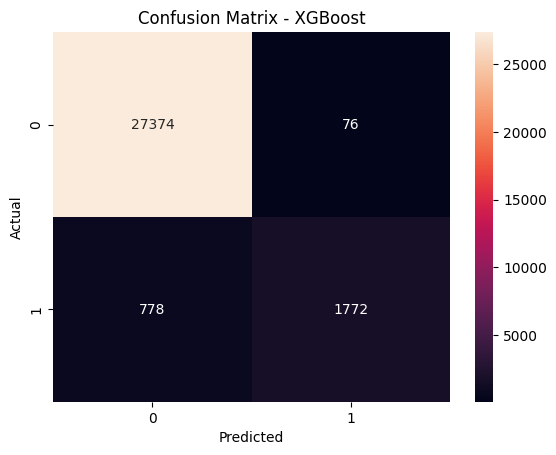

In [59]:
# =========================
# 11. CONFUSION MATRIX (MODEL TERBAIK)
# =========================
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()